<a href="https://colab.research.google.com/github/priyanka260604/first_gitrepo/blob/main/movie_review_binaryclassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data( num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [4]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [5]:
from keras import models
from keras import layers
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(optimizer='rmsprop',loss='binary_crossentropy', metrics=['accuracy'])



In [7]:
from keras import optimizers
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),loss='binary_crossentropy', metrics=['accuracy'])

In [8]:
from keras import losses
from keras import metrics
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001), loss=losses.binary_crossentropy, metrics=[metrics.binary_accuracy])

In [9]:
x_val = x_train[:10000]
partial_x_train =x_train[10000:]
y_val = y_train[:10000]
partial_y_train =y_train[10000:]

In [10]:
model.compile(optimizer='rmsprop',loss='binary_crossentropy', metrics=['acc'])
history = model.fit(partial_x_train,partial_y_train, epochs=20,batch_size=512,validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - acc: 0.7614 - loss: 0.5499 - val_acc: 0.8631 - val_loss: 0.4045
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.8915 - loss: 0.3277 - val_acc: 0.8789 - val_loss: 0.3231
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.9188 - loss: 0.2423 - val_acc: 0.8783 - val_loss: 0.2984
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - acc: 0.9343 - loss: 0.1950 - val_acc: 0.8901 - val_loss: 0.2748
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - acc: 0.9473 - loss: 0.1610 - val_acc: 0.8885 - val_loss: 0.2790
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - acc: 0.9547 - loss: 0.1389 - val_acc: 0.8782 - val_loss: 0.3025
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - acc: 0.9659 - loss: 0.1156 - val_acc: 0.8849 - val_loss: 0.3000
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.9672 - loss: 0.1028 - val_acc: 0.8756 - val_loss: 0.3254
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - acc: 0.9740

In [11]:
history_dict = history.history
history_dict.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

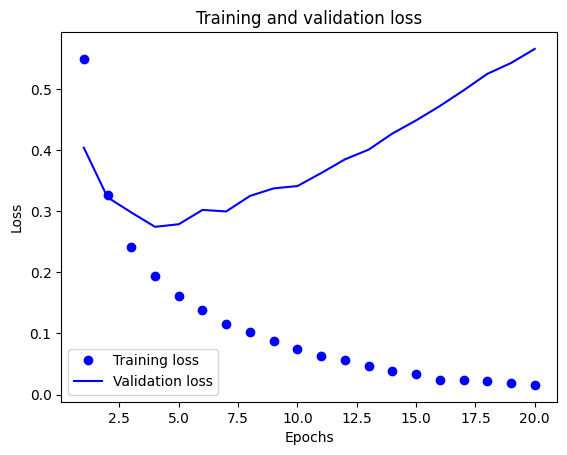

In [12]:
import matplotlib.pyplot as plt
history_dict = history.history
loss_values =history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1,len(history_dict['acc']) + 1)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

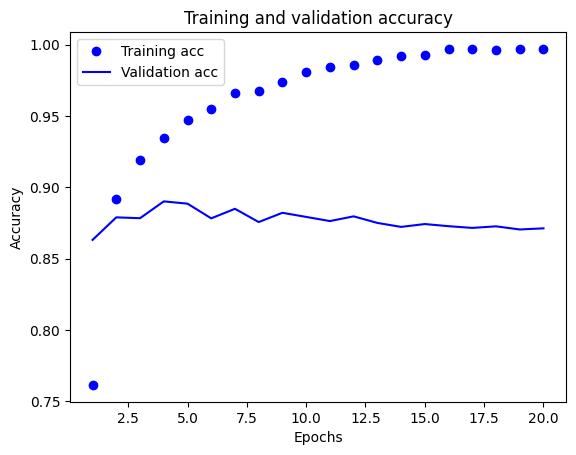

In [13]:
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [15]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[0.01346654],
       [1.        ],
       [0.9502293 ],
       ...,
       [0.00406844],
       [0.0172886 ],
       [0.9646112 ]], dtype=float32)